# Explore disk RLOF models

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from MESAreader import get_src_col
import matplotlib.gridspec as gridspec
import glob
%load_ext autoreload
%autoreload 2

Hardcoded some constants


In [15]:
root = "/home/mrenzo/Runs/disk_RLOF_MESA/runs/test1/"
hfileb = root+'/binary_history.data'
hfile2 = root+'LOGS2/history.data'
hfile1 = root+'LOGS1/history.data'

# plot fl2

... Binary file does not yet exist
... let me scrub this for you


Data in /home/mrenzo/Runs/disk_RLOF_MESA/runs/test1//binary_history.data has been scrubbed.
...    reading ascii file  /home/mrenzo/Runs/disk_RLOF_MESA/runs/test1//binary_history.data
...    and storing it for you in binary format
...    patience please, next time will be way faster 
...    I promise


Text(0, 0.5, '$\\int \\dot{M}_{1} f_{\\rm L2} dt \\ [M_{\\odot}]$')

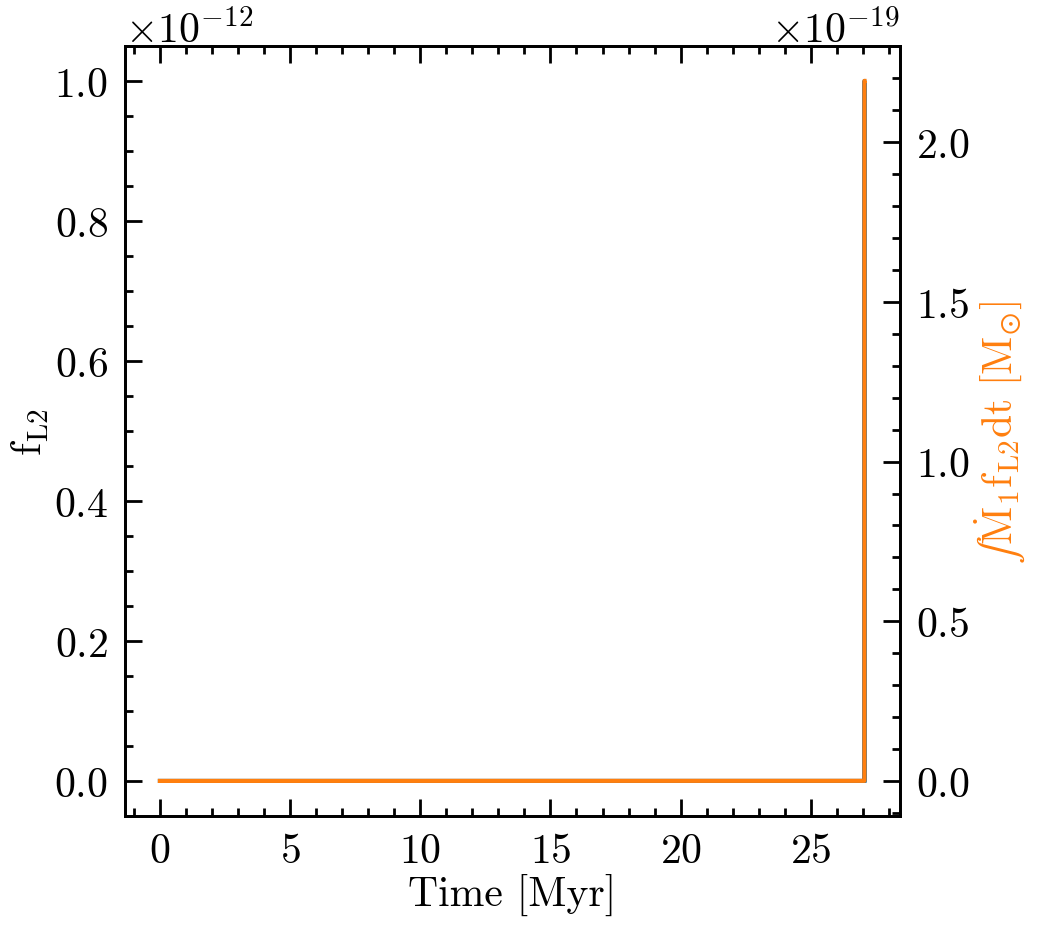

In [16]:
fig = plt.figure(figsize=(10,10))
gs = gridspec.GridSpec(100, 100)
ax = fig.add_subplot(gs[:, :])
bx = ax.twinx()

src, col = get_src_col(hfileb)
# for c in col: print(c)
t = src[:, col.index("age")]*1e-6
fl2 = src[:, col.index("fL2")]
mdot1 = 10.0**(src[:, col.index("lg_mstar_dot_1")])
dt = np.diff(t, append=0)
ax.plot(t, fl2)
bx.plot(t, np.cumsum(mdot1*fl2*dt), c='C1')

ax.set_ylabel(r"$f_{\rm L2}$")
ax.set_xlabel(r"Time [Myr]")
bx.set_ylabel(r"$\int \dot{M}_{1} f_{\rm L2} dt \ [M_{\odot}]$", c="C1")

# Radial expansion of accretor with rotation

In [27]:
def plot_R(hfile, ax, **kwargs):
    src, col = get_src_col(hfile)
    R = 10.0**(src[:, col.index("log_R")])
    t = src[:, col.index("star_age")]*1e-6
    ax.scatter(t, R, **kwargs)

(27.06, 27.063)

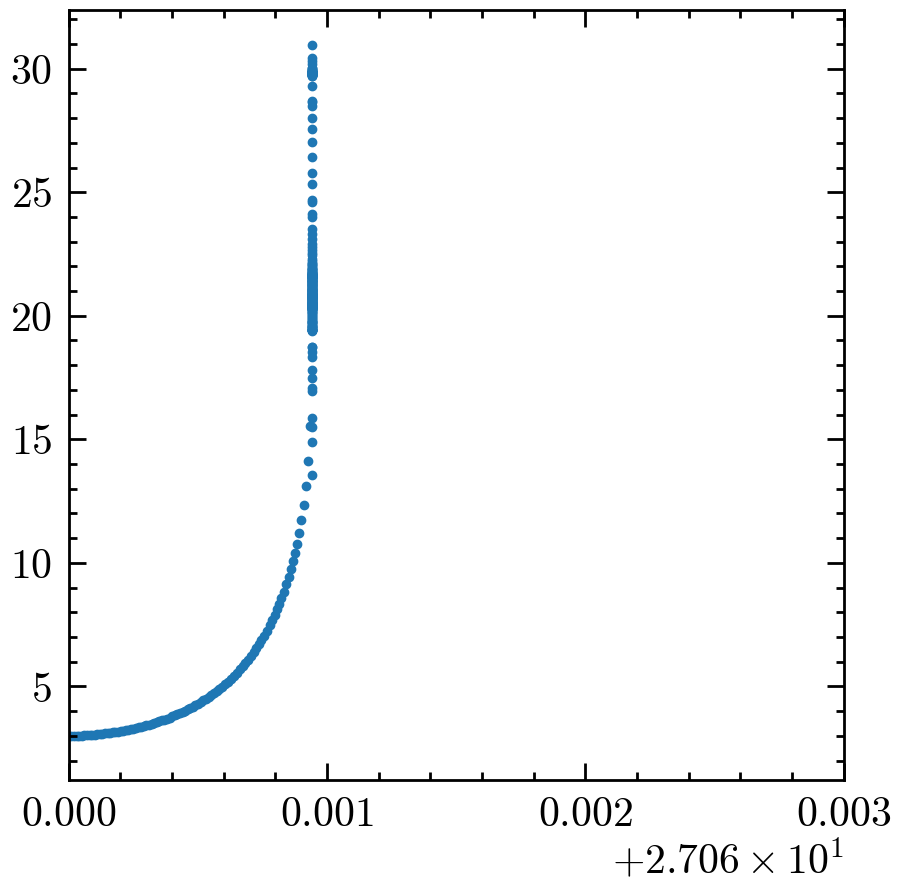

In [32]:
fig = plt.figure(figsize=(10,10))
gs = gridspec.GridSpec(100, 100)
ax = fig.add_subplot(gs[:, :])
plot_R(hfile2, ax)
ax.set_xlim(xmin=27.06, xmax=27.063)